# Commentary Generation & Evaluation Pipeline

1. **Generation**: NL move commentary (Chernev-style, no ground truth)
2. **LLM-as-Judge**: Tool-augmented atom decomposition + factual verification

In [104]:
import json
import os
import math
import random
import numpy as np
import chess
import chess.engine
import chess.svg
from IPython.display import display, SVG, Markdown, HTML
from dotenv import load_dotenv
from dataclasses import dataclass

load_dotenv()

STOCKFISH_PATH = '/opt/homebrew/bin/stockfish'
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), '')

K = 0.00368208

def cp_to_winpct(cp):
    """Lichess win% formula."""
    return 50 + 50 * math.tanh(K * cp / 2)


def get_engine_analysis(fen, move_uci=None, depth=22, multipv=3):
    """Get Stockfish top lines. If move_uci given and not in top-N, fetch separately."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=depth), multipv=multipv)
        lines = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:8]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                eval_str = f'M{mate}' if mate is not None else f'{cp/100:+.2f}'
                lines.append({
                    'move_uci': pv[0].uci(), 'move_san': board.san(pv[0]),
                    'eval': eval_str, 'pv_san': ' '.join(san_moves),
                    'cp': cp, 'mate': mate, 'is_top': True,
                })

        if move_uci is not None:
            if not any(l['move_uci'] == move_uci for l in lines):
                move_obj = chess.Move.from_uci(move_uci)
                move_san = board.san(move_obj)
                b2 = board.copy()
                b2.push(move_obj)
                info2 = engine.analyse(b2, chess.engine.Limit(depth=depth))
                sc2 = info2['score'].white()
                cp2 = sc2.score(mate_score=10000)
                mate2 = sc2.mate()
                eval2 = f'M{mate2}' if mate2 is not None else f'{cp2/100:+.2f}'
                pv2 = info2.get('pv', [])
                pv_sans = [move_san]
                b3 = b2.copy()
                for m in pv2[:7]:
                    pv_sans.append(b3.san(m))
                    b3.push(m)
                lines.append({
                    'move_uci': move_uci, 'move_san': move_san,
                    'eval': eval2, 'pv_san': ' '.join(pv_sans),
                    'cp': cp2, 'mate': mate2, 'is_top': False,
                })

    return lines

print('Helpers loaded.')

Helpers loaded.


In [105]:
ACCEPTED_PATH = os.path.join(os.getcwd(), 'review_accepted.jsonl')

# Primary data: accepted gold extractions (with gold atoms for eval)
with open(ACCEPTED_PATH) as f:
    accepted_positions = [json.loads(line) for line in f]

# Raw entries — only needed for find_entry() used by demo builder
with open(os.path.join(DATA_DIR, 'logical_chess_optimal_move.jsonl')) as f:
    optimal_moves = [json.loads(line) for line in f]
with open(os.path.join(DATA_DIR, 'logical_chess_other_move.jsonl')) as f:
    other_moves = [json.loads(line) for line in f]
_all_raw = optimal_moves + other_moves

def find_entry(fen, move_uci):
    """Search raw datasets (for demo builder)."""
    for e in _all_raw:
        if e['fen'] == fen and e['move_uci'] == move_uci:
            return e
    raise ValueError(f'Not found: {fen} {move_uci}')

print(f'Accepted positions: {len(accepted_positions)}')
print(f'Raw entries (for demos): {len(_all_raw)}')

Accepted positions: 39
Raw entries (for demos): 1832


---
## Demo Review

Review the 5 demo outputs (written from atoms, NOT copied from Chernev).
These will be the few-shot examples for generation. Stored in `review_demo.jsonl`.

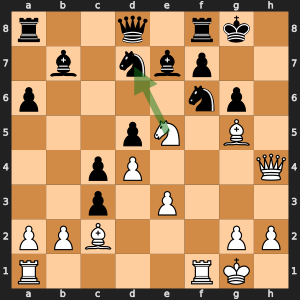

### Demo 1 — [3] Pillsbury – Marco
**White plays Nxd7** (good, wp_loss=-0.4%)

`r2q1rk1/1b1nbp2/p4np1/3pN1B1/2pP3Q/2p1P3/PPB3PP/R4RK1 w - - 0 18`

**Gold atoms:**
- Nxd7 removes one of the supporting pieces for Black's knight on f6.

**Chernev:** This removes one of the props supporting the knight.

**Proposed demo output:**
> Nxd7 removes one of the pieces defending Black's knight on f6, undermining its support.

---

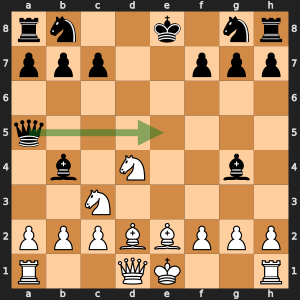

### Demo 2 — [20] Tarrasch – Mieses
**Black plays Qe5** (good, wp_loss=0.0%)

`rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8`

**Gold atoms:**
- Qe5 pins the Be2 to the king on e1.
- Qe5 attacks the unprotected Nd4.
- Rejects Bxe2 due to 9.Qxe2+, which gains White a tempo.

**Chernev:** Black’s response pins the e2-bishop and attacks the unprotected d4-knight. Black rejects 8... Bxe2 as the recapture by 9 Qxe2+ gains another tempo for White.

**Proposed demo output:**
> Qe5 pins the bishop on e2 against the king on e1, while simultaneously attacking the unprotected knight on d4. Black avoids 8...Bxe2 because after 9.Qxe2+, White gains a tempo with the check.

---

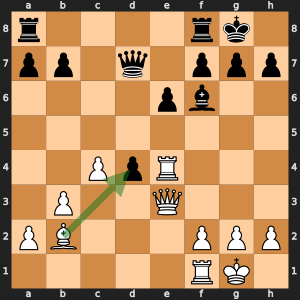

### Demo 3 — [4] Capablanca – Villegas
**White plays Bxd4** (good, wp_loss=0.0%)

`r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19`

**Gold atoms:**
- Regains the pawn on d4.
- The bishop on d4 attacks both the a7-pawn and threatens a mating sequence starting with Bxf6.

**Variation:** `Bxf6 gxf6 21.Rg4+ Kh8 22.Qh6 Rg8 23.Qxf6+`

**Chernev:** White regains the pawn, and his bishop now attacks in two directions. On the one hand, it threatens to take the a-pawn, on the other it aims at checkmate by... Bxf6 gxf6 21 Rg4+ Kh8 22 Qh6 Rg8 23 Qxf6+ and mate next move.

**Proposed demo output:**
> Bxd4 regains the pawn, and from d4 the bishop attacks in two directions: it threatens the a7-pawn, and it sets up a mating attack via Bxf6 gxf6, Rg4+ Kh8, Qh6 Rg8, Qxf6+ with mate to follow.

---

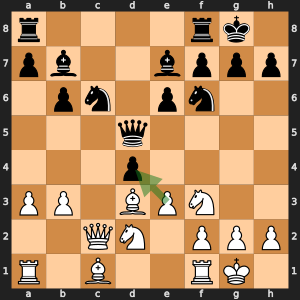

### Demo 4 — [31] Flohr – Pitschak
**White plays exd4** (bad, wp_loss=9.2%)

`r4rk1/pb2bppp/1pn1pn2/3q4/3p4/PP1BPN2/2QN1PPP/R1B2RK1 w - - 0 12`

**Gold atoms:**
- White opens the position to get some counterplay.
- White hopes to use the e-file for the rook and the e4-square as a pivot for pieces.

**Alternative: e4**
- Playing e4 occupies the e4-square with a pawn, making it unavailable for piece maneuvering.
- Black gains an extra passed pawn on the d-file.

**Chernev:** White opens the position to get some counterplay; he hopes to utilize the e-file for his rook and the e4-square as a pivot for his pieces.
Instead the superficially attractive 12 e4 does not accomplish much, as after 12... Qh5 the vital e4-square is occupied by a pawn, making it unavailable for the manoeuvring of pieces, while Black benefits in having an extra passed pawn on the d-file.

**Proposed demo output:**
> exd4 opens the position to create counterplay — White wants to use the e-file for the rook and the e4-square as a pivot for piece maneuvering. The alternative 12.e4 looks natural but after 12...Qh5, the e4-square is blocked by White's own pawn, removing it as an outpost, and Black gains a dangerous passed d-pawn.

---

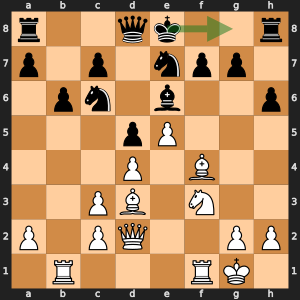

### Demo 5 — [37] Blackburne – Blanchard
**Black plays O-O** (mistake, wp_loss=24.1%)

`r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12`

**Gold atoms:**
- Castles into White's prepared kingside attack.
- White's one weakness is the doubled c-pawns — Black should be exploiting that instead.

**Alternative: Na5**
- Reroutes the knight toward c4, where it blockades the doubled c-pawn.
- Interferes with the free movement of White's pieces.
- If White captures (Bxc4 dxc4), White's pawn structure becomes inferior to Black's.
- Black can anchor a piece on d5, which cannot be evicted by pawns.

**Chernev:** Walking right into the teeth of the storm!
Before making a move that suggests itself so readily, Black might have asked himself, “How can I exploit White’s one weakness, the doubled pawns on the c-file?”
He might then have hit upon 12... Na5, with the object of swinging the knight to c4. There it blockades the doubled pawn, interferes with the free movement of White’s pieces, and in general sticks like a bone in the throat. White could capture the knight, but then he parts with one of his valuable bishops, and as a result of the exchange his pawn position would be inferior to Black’s. Finally, Black could then anchor one of his pieces to great effect on d5, a square from which it could never be evicted by pawns.

**Proposed demo output:**
> Castling walks straight into White's prepared kingside attack. Instead, Black should exploit White's one weakness — the doubled c-pawns — with Na5, rerouting the knight toward c4. On c4, the knight blockades the doubled pawn, restricts White's pieces, and if White captures with Bxc4 dxc4, White's pawn structure becomes inferior. Black could also anchor a piece on d5, a square that pawns can never challenge.

---

In [96]:
# Load demos and display for review
DEMO_PATH = os.path.join(os.getcwd(), 'review_demo.jsonl')
with open(DEMO_PATH) as f:
    review_demos = [json.loads(line) for line in f]

for di, demo in enumerate(review_demos):
    board = chess.Board(demo['fen'])
    move = chess.Move.from_uci(demo['move_uci'])
    is_bad = demo.get('quality', 'good') in ('bad', 'blunder', 'mistake', 'inaccuracy')
    arrow_color = '#cc0000' if is_bad else '#15781B'

    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)],
                          colors={'arrow': arrow_color}, size=300)
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    display(Markdown(
        f'### Demo {di+1} — [{demo["accepted_idx"]}] {demo["game"]}\n'
        f'**{turn} plays {demo["move_san"]}** '
        f'({demo["quality"]}, wp_loss={demo["wp_loss"]:.1f}%)\n\n'
        f'`{demo["fen"]}`'
    ))

    ext = demo['extracted']
    atoms = ext.get('reasoning', [])
    display(Markdown('**Gold atoms:**\n' + '\n'.join(f'- {a}' for a in atoms)))

    if ext.get('variation'):
        display(Markdown(f'**Variation:** `{ext["variation"]}`'))
    if ext.get('alternative'):
        alt = ext['alternative']
        alt_atoms = alt.get('reasoning', [])
        display(Markdown(
            f'**Alternative: {alt["move"]}**\n' +
            '\n'.join(f'- {a}' for a in alt_atoms)
        ))

    display(Markdown(f'**Chernev:** {demo.get("annotation", "(n/a)")}'))

    display(Markdown(f'**Proposed demo output:**\n> {demo["demo_output"]}'))
    display(Markdown('---'))

---
## Generation Template

Generate natural language move commentary given **only** FEN + move + engine analysis.

Few-shot demos loaded from `review_demo.jsonl` (atom-derived NL, not copied from Chernev).

In [106]:
# ── Generation system prompt ──────────────────────────────────────────────

GEN_SYSTEM_PROMPT = """\
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN), the move played, and engine analysis, write a concise, \
instructive explanation of the move.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. \
A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers."""

GEN_RAW_SYSTEM_PROMPT = """\
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN) and the move played, write a concise, instructive \
explanation of the move. You have access to chess analysis tools — use them \
to understand the position before writing your explanation.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. \
A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers."""


# ── ASCII board helper ───────────────────────────────────────────────────

def fen_to_ascii(fen):
    """Convert FEN to ASCII board representation."""
    return str(chess.Board(fen))


def build_gen_user_prompt(entry, engine_lines, ascii=False):
    """Build user prompt for generation: FEN + move + engine (NO commentary).
    If ascii=True, include ASCII board representation."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))

    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)

    pv_text = []
    for i, line in enumerate(top_lines, 1):
        pv_text.append(f"  {i}. {line['move_san']} ({line['eval']}): {line['pv_san']}")

    wp_loss = entry.get('wp_loss', 0)
    if wp_loss > 20:
        quality_hint = f" [BLUNDER — wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 5:
        quality_hint = f" [SUBOPTIMAL — wp_loss: {wp_loss:.1f}%]"
    else:
        quality_hint = f" [wp_loss: {wp_loss:.1f}%]"

    prompt = f"FEN: {entry['fen']}\n"
    if ascii:
        prompt += f"Board:\n{fen_to_ascii(entry['fen'])}\n"
    prompt += (
        f"Move played: {move_san}{quality_hint}\n"
        f"Engine top-3:\n" + "\n".join(pv_text) + "\n"
    )

    if played_line:
        prompt += (
            f"Played move eval:\n"
            f"  {played_line['move_san']} ({played_line['eval']}): {played_line['pv_san']}\n"
        )

    return prompt


def build_gen_user_prompt_raw(entry, ascii=False):
    """Build user prompt for raw generation: FEN + move only (no engine info).
    If ascii=True, include ASCII board representation."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))
    prompt = f"FEN: {entry['fen']}\n"
    if ascii:
        prompt += f"Board:\n{fen_to_ascii(entry['fen'])}\n"
    prompt += f"Move played: {move_san}\n"
    return prompt


# ── Build demo messages from review_demo.jsonl ───────────────────────────

print("Building generation demos from review_demo.jsonl...")

GEN_DEMOS = []
GEN_RAW_DEMOS = []

for demo in review_demos:
    entry = {'fen': demo['fen'], 'move_uci': demo['move_uci'],
             'wp_loss': demo.get('wp_loss', 0)}
    el = demo.get('engine_lines') or get_engine_analysis(demo['fen'], demo['move_uci'])
    user_prompt = build_gen_user_prompt(entry, el)
    GEN_DEMOS.append({"role": "user", "content": user_prompt})
    GEN_DEMOS.append({"role": "assistant", "content": demo['demo_output']})

    raw_prompt = build_gen_user_prompt_raw(entry)
    GEN_RAW_DEMOS.append({"role": "user", "content": raw_prompt})
    GEN_RAW_DEMOS.append({"role": "assistant", "content": demo['demo_output']})

    board = chess.Board(demo['fen'])
    san = board.san(chess.Move.from_uci(demo['move_uci']))
    print(f"  {san} ({demo.get('quality', '?')}): done")

print(f"\nGeneration template ready: {len(GEN_DEMOS)//2} demos")
print(f"\nSample input:\n{GEN_DEMOS[0]['content']}")
print(f"\nSample output:\n{GEN_DEMOS[1]['content']}")
print(f"\nSample raw input:\n{GEN_RAW_DEMOS[0]['content']}")

Building generation demos from review_demo.jsonl...
  Nxd7 (good): done
  Qe5 (good): done
  Bxd4 (good): done
  exd4 (bad): done
  O-O (mistake): done

Generation template ready: 5 demos

Sample input:
FEN: r2q1rk1/1b1nbp2/p4np1/3pN1B1/2pP3Q/2p1P3/PPB3PP/R4RK1 w - - 0 18
Move played: Nxd7 [wp_loss: -0.4%]
Engine top-3:
  1. bxc3 (+4.38): bxc3 Qa5 Nxd7 Nxd7 Bxe7 Qxc3 Ba4 Rae8
  2. Nxd7 (+3.92): Nxd7 Nh5 Bxg6 fxg6 Rxf8+ Qxf8 Nxf8 cxb2
  3. Rf3 (+2.89): Rf3 Nxe5 dxe5 Nh5 Bxe7 cxb2 Raf1 Qb6


Sample output:
Nxd7 removes one of the pieces defending Black's knight on f6, undermining its support.

Sample raw input:
FEN: r2q1rk1/1b1nbp2/p4np1/3pN1B1/2pP3Q/2p1P3/PPB3PP/R4RK1 w - - 0 18
Move played: Nxd7



In [107]:
# ── Chess Tool Functions ──────────────────────────────────────────────────

import json as _json

def tool_get_legal_moves(fen):
    board = chess.Board(fen)
    moves = [board.san(m) for m in board.legal_moves]
    return _json.dumps({"moves": moves, "count": len(moves)})

def tool_get_piece_at(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"square": square, "piece": "empty"})
    color = "white" if p.color == chess.WHITE else "black"
    return _json.dumps({"square": square, "piece": f"{color} {chess.piece_name(p.piece_type)}"})

def tool_get_attacks(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    attacks = sorted([chess.square_name(a) for a in board.attacks(sq)])
    return _json.dumps({"piece": p.symbol(), "square": square, "attacks": attacks})

def tool_get_attackers(fen, square, color):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    c = chess.WHITE if color == "white" else chess.BLACK
    attackers = [[chess.piece_name(board.piece_at(a).piece_type), chess.square_name(a)]
                 for a in board.attackers(c, sq)]
    return _json.dumps({"square": square, "color": color, "attackers": attackers})

def tool_is_pinned(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    pinned = board.is_pinned(p.color, sq)
    result = {"square": square, "pinned": pinned}
    if pinned:
        result["pin_ray"] = str(chess.SquareSet(board.pin(p.color, sq)))
    return _json.dumps(result)

def tool_is_check(fen):
    board = chess.Board(fen)
    in_check = board.is_check()
    result = {"in_check": in_check}
    if in_check:
        result["checkers"] = [chess.square_name(sq) for sq in board.checkers()]
    return _json.dumps(result)

def tool_try_variation(fen, moves):
    board = chess.Board(fen)
    played = []
    for san in moves:
        try:
            move = board.parse_san(san)
            played.append(board.san(move))
            board.push(move)
        except Exception as e:
            return _json.dumps({"legal": False, "error": f"{san}: {str(e)}", "played": played})
    result = {"legal": True, "played": played, "resulting_fen": board.fen()}
    if board.is_checkmate():
        result["eval"] = "checkmate"
    elif board.is_stalemate():
        result["eval"] = "stalemate"
    else:
        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
            info = engine.analyse(board, chess.engine.Limit(depth=18))
            sc = info['score'].white()
            mate = sc.mate()
            result["eval"] = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
    return _json.dumps(result)

def tool_get_engine_eval(fen, depth=20):
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        sc = info['score'].white()
        pv = info.get('pv', [])
        mate = sc.mate()
        ev = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
        best = board.san(pv[0]) if pv else "?"
    return _json.dumps({"eval": ev, "best_move": best})

def tool_get_top_moves(fen, n=3, depth=20):
    """Get top N engine moves with evals and principal variations."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=int(depth)), multipv=int(n))
        moves = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:6]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                ev = f"M{mate}" if mate is not None else f"{cp/100:+.2f}"
                moves.append({
                    "move": board.san(pv[0]),
                    "eval": ev,
                    "pv": " ".join(san_moves),
                })
    return _json.dumps({"top_moves": moves})

def tool_eval_move(fen, move, depth=20):
    """Evaluate a specific move: returns eval after the move, best move, and wp_loss."""
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        # Root position analysis: best move + eval
        root_info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        root_cp = root_info['score'].white().score(mate_score=10000)
        root_pv = root_info.get('pv', [])
        best_move_san = board.san(root_pv[0]) if root_pv else "?"

        # Eval after the given move
        m = board.parse_san(move)
        move_san = board.san(m)
        b2 = board.copy()
        b2.push(m)
        move_info = engine.analyse(b2, chess.engine.Limit(depth=int(depth)))
        move_cp = move_info['score'].white().score(mate_score=10000)
        move_mate = move_info['score'].white().mate()
        move_eval_str = f"M{move_mate}" if move_mate is not None else f"{move_cp/100:+.2f}"

    # wp_loss from the moving side's perspective
    if board.turn == chess.WHITE:
        wp_loss_val = wp(root_cp) - wp(move_cp)
    else:
        wp_loss_val = wp(move_cp) - wp(root_cp)
    wp_loss_val = round(max(0, wp_loss_val), 1)

    quality = "good" if wp_loss_val < 5 else ("bad" if wp_loss_val < 20 else "blunder")

    return _json.dumps({
        "move": move_san,
        "move_eval": move_eval_str,
        "best_move": best_move_san,
        "wp_loss": wp_loss_val,
        "quality": quality,
    })

def tool_compare_moves(fen, move_a, move_b, depth=20):
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        ba = board.copy(); ba.push(board.parse_san(move_a))
        ia = engine.analyse(ba, chess.engine.Limit(depth=int(depth)))
        sa = ia['score'].white().score(mate_score=10000)
        bb = board.copy(); bb.push(board.parse_san(move_b))
        ib = engine.analyse(bb, chess.engine.Limit(depth=int(depth)))
        sb = ib['score'].white().score(mate_score=10000)
    return _json.dumps({
        "move_a": move_a, "eval_a": f"{sa/100:+.2f}",
        "move_b": move_b, "eval_b": f"{sb/100:+.2f}",
        "wp_diff": round(abs(wp(sa) - wp(sb)), 1)
    })

def tool_make_move(fen, move):
    board = chess.Board(fen)
    m = board.parse_san(move)
    gives_check = board.gives_check(m)
    board.push(m)
    return _json.dumps({"fen": board.fen(), "gives_check": gives_check})

_PIECE_NAMES = {"pawn": chess.PAWN, "knight": chess.KNIGHT, "bishop": chess.BISHOP,
                "rook": chess.ROOK, "queen": chess.QUEEN, "king": chess.KING}

def tool_get_squares(fen, piece, color=None):
    """Find all squares occupied by a piece type, optionally filtered by color.
    piece: 'pawn','knight','bishop','rook','queen','king'
    color: 'white','black', or omit for both."""
    board = chess.Board(fen)
    pt = _PIECE_NAMES.get(piece.lower())
    if pt is None:
        return _json.dumps({"error": f"unknown piece: {piece}. Use pawn/knight/bishop/rook/queen/king"})
    colors = []
    if color is None:
        colors = [chess.WHITE, chess.BLACK]
    elif color == "white":
        colors = [chess.WHITE]
    elif color == "black":
        colors = [chess.BLACK]
    else:
        return _json.dumps({"error": f"unknown color: {color}. Use white/black"})
    results = []
    for c in colors:
        cname = "white" if c == chess.WHITE else "black"
        for sq in board.pieces(pt, c):
            results.append({"square": chess.square_name(sq), "color": cname})
    return _json.dumps({"piece": piece, "squares": results})

def tool_get_material(fen):
    """Get material count for both sides."""
    board = chess.Board(fen)
    result = {}
    for color_name, color in [("white", chess.WHITE), ("black", chess.BLACK)]:
        pieces = {}
        for pt, name in [(chess.PAWN, "pawns"), (chess.KNIGHT, "knights"),
                         (chess.BISHOP, "bishops"), (chess.ROOK, "rooks"),
                         (chess.QUEEN, "queens")]:
            count = len(board.pieces(pt, color))
            if count > 0:
                pieces[name] = count
        result[color_name] = pieces
    return _json.dumps(result)


TOOL_FUNCTIONS = {
    "get_legal_moves": tool_get_legal_moves, "get_piece_at": tool_get_piece_at,
    "get_attacks": tool_get_attacks, "get_attackers": tool_get_attackers,
    "is_pinned": tool_is_pinned, "is_check": tool_is_check,
    "try_variation": tool_try_variation, "get_engine_eval": tool_get_engine_eval,
    "get_top_moves": tool_get_top_moves, "eval_move": tool_eval_move,
    "compare_moves": tool_compare_moves, "make_move": tool_make_move,
    "get_squares": tool_get_squares, "get_material": tool_get_material,
}

def _schema(name, desc, props, required):
    return {"type": "function", "function": {"name": name, "description": desc,
            "parameters": {"type": "object", "properties": props, "required": required}}}

_fen_prop = {"fen": {"type": "string", "description": "FEN of the position"}}
_sq_prop = {"square": {"type": "string", "description": "Square name, e.g. 'd3'"}}

TOOL_SCHEMAS_OPENAI = [
    _schema("get_legal_moves", "Get all legal moves in SAN.", _fen_prop, ["fen"]),
    _schema("get_piece_at", "Get the piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attacks", "Get squares attacked by piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attackers", "Get pieces of a color attacking a square.",
            {**_fen_prop, **_sq_prop, "color": {"type": "string", "enum": ["white", "black"]}},
            ["fen", "square", "color"]),
    _schema("is_pinned", "Check if a piece is pinned.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("is_check", "Check if side to move is in check.", _fen_prop, ["fen"]),
    _schema("try_variation", "Try a sequence of SAN moves from a position. Returns resulting FEN for further analysis.",
            {**_fen_prop, "moves": {"type": "array", "items": {"type": "string"}}}, ["fen", "moves"]),
    _schema("get_engine_eval", "Get Stockfish eval + best move.",
            {**_fen_prop, "depth": {"type": "integer"}}, ["fen"]),
    _schema("get_top_moves", "Get top N engine moves with evals and principal variations (PV lines). Use this to explore what's best in any position.",
            {**_fen_prop, "n": {"type": "integer", "description": "Number of top moves (default 3)"},
             "depth": {"type": "integer", "description": "Search depth (default 20)"}},
            ["fen"]),
    _schema("eval_move", "Evaluate a specific move: returns eval after the move, the engine's best move, wp_loss (win% lost vs best), and quality (good/bad/blunder). Use this to check if a move or continuation is actually good.",
            {**_fen_prop, "move": {"type": "string", "description": "Move in SAN notation"},
             "depth": {"type": "integer", "description": "Search depth (default 20)"}},
            ["fen", "move"]),
    _schema("compare_moves", "Compare eval of two moves.",
            {**_fen_prop, "move_a": {"type": "string"}, "move_b": {"type": "string"},
             "depth": {"type": "integer"}}, ["fen", "move_a", "move_b"]),
    _schema("make_move", "Make a move, return new FEN.",
            {**_fen_prop, "move": {"type": "string"}}, ["fen", "move"]),
    _schema("get_squares", "Find all squares of a piece type, optionally by color. E.g. get_squares(fen, 'rook', 'white') → all white rook squares.",
            {**_fen_prop, "piece": {"type": "string", "enum": ["pawn","knight","bishop","rook","queen","king"]},
             "color": {"type": "string", "enum": ["white", "black"], "description": "Optional color filter"}},
            ["fen", "piece"]),
    _schema("get_material", "Get material count (piece types and counts) for both sides.", _fen_prop, ["fen"]),
]

TOOL_SCHEMAS_ANTHROPIC = [
    {"name": s["function"]["name"], "description": s["function"]["description"],
     "input_schema": s["function"]["parameters"]} for s in TOOL_SCHEMAS_OPENAI
]

def execute_tool(name, arguments):
    fn = TOOL_FUNCTIONS.get(name)
    if fn is None:
        return _json.dumps({"error": f"unknown tool: {name}"})
    try:
        return fn(**arguments)
    except Exception as e:
        return _json.dumps({"error": str(e)})


# ── API Abstraction ───────────────────────────────────────────────────────

@dataclass
class ToolCall:
    id: str
    name: str
    arguments: dict

@dataclass
class LLMResponse:
    text: str
    tool_calls: list


def call_openai(messages, tools=None, model="gpt-4o", temperature=0.3):
    import openai
    client = openai.OpenAI()
    # Newer models (gpt-4.1+, gpt-5+) use max_completion_tokens
    token_key = "max_completion_tokens" if any(m in model for m in ("gpt-4.1", "gpt-5", "o3", "o4")) else "max_tokens"
    kwargs = dict(model=model, messages=messages, temperature=temperature, **{token_key: 2048})
    if tools:
        kwargs["tools"] = tools
        kwargs["tool_choice"] = "auto"
    resp = client.chat.completions.create(**kwargs)
    msg = resp.choices[0].message
    text = msg.content or ""
    tc = []
    if msg.tool_calls:
        for c in msg.tool_calls:
            tc.append(ToolCall(id=c.id, name=c.function.name,
                               arguments=_json.loads(c.function.arguments)))
    return LLMResponse(text=text, tool_calls=tc), msg


def call_anthropic(messages, tools=None, model="claude-sonnet-4-5-20250929",
                   system=None, temperature=0.3):
    import anthropic
    client = anthropic.Anthropic()
    kwargs = dict(model=model, max_tokens=2048, temperature=temperature)
    if system:
        kwargs["system"] = system
    api_messages = [m for m in messages if m["role"] != "system"]
    kwargs["messages"] = api_messages
    if tools:
        kwargs["tools"] = tools
    resp = client.messages.create(**kwargs)
    text = ""
    tc = []
    for block in resp.content:
        if block.type == "text":
            text += block.text
        elif block.type == "tool_use":
            tc.append(ToolCall(id=block.id, name=block.name, arguments=block.input))
    return LLMResponse(text=text, tool_calls=tc), resp


def call_llm(messages, tools=None, provider="openai", model=None, temperature=0.3):
    if provider == "openai":
        return call_openai(messages, tools=tools, model=model or "gpt-4o", temperature=temperature)
    elif provider == "anthropic":
        m = model or "claude-sonnet-4-5-20250929"
        sys_msg = next((msg["content"] for msg in messages if msg["role"] == "system"), None)
        return call_anthropic(messages, tools=tools, model=m, system=sys_msg, temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")


# ── Generation & Tool-calling ─────────────────────────────────────────────

PROVIDER = "openai"
MODEL = "gpt-4o"
MAX_TOOL_ROUNDS = 10


def _call_with_tools(messages, provider=PROVIDER, model=MODEL, temperature=0.3,
                     max_rounds=MAX_TOOL_ROUNDS, verbose=True):
    """Run LLM with tool access, handling multi-round tool calls.
    Returns (final_text, tool_log)."""
    tool_schemas = TOOL_SCHEMAS_OPENAI if provider == "openai" else TOOL_SCHEMAS_ANTHROPIC
    tool_log = []

    for _ in range(max_rounds):
        resp, raw = call_llm(messages, tools=tool_schemas, provider=provider,
                             model=model, temperature=temperature)

        if not resp.tool_calls:
            return resp.text.strip() if resp.text else "", tool_log

        if provider == "openai":
            messages.append({
                "role": "assistant", "content": resp.text or None,
                "tool_calls": [{"id": tc.id, "type": "function",
                                "function": {"name": tc.name,
                                             "arguments": _json.dumps(tc.arguments)}}
                               for tc in resp.tool_calls],
            })
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                if verbose:
                    print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})
        elif provider == "anthropic":
            content_blocks = []
            if resp.text:
                content_blocks.append({"type": "text", "text": resp.text})
            for tc in resp.tool_calls:
                content_blocks.append({"type": "tool_use", "id": tc.id,
                                       "name": tc.name, "input": tc.arguments})
            messages.append({"role": "assistant", "content": content_blocks})
            tool_results = []
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                if verbose:
                    print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                tool_results.append({"type": "tool_result", "tool_use_id": tc.id,
                                     "content": result})
            messages.append({"role": "user", "content": tool_results})

    return resp.text.strip() if resp.text else "[max tool rounds]", tool_log


def generate_commentary(entry, engine_lines, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate natural language move commentary with optional tool calls.
    Returns (text, tool_log)."""
    messages = [{"role": "system", "content": GEN_SYSTEM_PROMPT}]
    messages.extend(GEN_DEMOS)
    messages.append({"role": "user", "content": build_gen_user_prompt(entry, engine_lines, ascii=ascii)})
    return _call_with_tools(messages, provider=provider, model=model, temperature=0.3)


def generate_commentary_raw(entry, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate commentary from FEN + move only (no engine info).
    LLM must use tools to analyze the position. Returns (text, tool_log)."""
    messages = [{"role": "system", "content": GEN_RAW_SYSTEM_PROMPT}]
    messages.extend(GEN_RAW_DEMOS)
    messages.append({"role": "user", "content": build_gen_user_prompt_raw(entry, ascii=ascii)})
    return _call_with_tools(messages, provider=provider, model=model, temperature=0.3)


print(f"API ready. Provider: {PROVIDER}, Model: {MODEL}")
print(f"Tools: {len(TOOL_FUNCTIONS)}")


API ready. Provider: openai, Model: gpt-4o
Tools: 14


---
## LLM-as-Judge

Tool-augmented atom-level evaluation:

1. **Decompose** candidate explanation into atomic claims
2. **Verify** each atom against the position using chess tools → **Factual Precision**
3. **Match** against gold atoms → **Recall**
4. **Quality check**: does explanation correctly assess the move?

In [108]:
# ── JSON parsing helper ───────────────────────────────────────────────────

def _parse_judge_json(text):
    """Parse JSON from judge LLM output, handling markdown fences."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print(f"  [JSON parse error] {text[:200]}...")
        return {}


# ── Step 1: Decompose NL into atoms ──────────────────────────────────────

DECOMPOSE_SYSTEM = """\
Extract atomic factual claims from a chess move explanation.

Each atom = ONE verifiable claim about the position, a piece, a square, \
a variation, or an evaluation.

RULES:
1. Be specific — include piece names, squares, and concrete assertions.
2. Group logically connected setup+consequence as one atom.
   E.g., "f4 supports Ne5 AND after Nxe5 fxe5 opens the f-file" = one atom.
3. Each atom must be self-contained with full positional context. If an atom \
references a position after a sequence of moves, include the FULL preceding \
move sequence so it can be verified independently.

EXAMPLE — given this text:
"Nxd7 removes one of the defenders of the knight on f6, aiming to undermine \
Black's kingside defenses. After the expected Nh5, White can capture the \
bishop on g6, opening up Black's king to further attacks."

BAD atoms (later atoms lose context):
- "Nxd7 removes one of the defenders of the knight on f6."
- "After Nxd7, the expected move is Nh5."
- "After Nh5, White can capture the bishop on g6."  ← Nh5 from where?
- "Capturing the bishop on g6 opens up Black's king."  ← after what sequence?

GOOD atoms (each carries full move sequence from root):
- "Nxd7 removes one of the defenders of the knight on f6."
- "After Nxd7, the expected move is Nh5."
- "After Nxd7, Nh5, White can capture the bishop on g6."
- "After Nxd7, Nh5 — capturing the bishop on g6 opens up Black's king to \
further attacks."

4. Ignore stylistic flourishes that make no factual claim.
5. Ignore generic chess philosophy not applied to this position.

Output valid JSON: {"atoms": ["claim 1", "claim 2", ...]}"""


def decompose_to_atoms(text, provider=PROVIDER, model=MODEL):
    """Decompose natural language explanation into atomic factual claims.
    Returns list of atom strings."""
    messages = [
        {"role": "system", "content": DECOMPOSE_SYSTEM},
        {"role": "user", "content": text},
    ]
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    return data.get('atoms', [])


# ── Step 2: Verify atoms with tools ──────────────────────────────────────

VERIFY_SYSTEM = """\
You are a chess position fact-checker with access to analysis tools.

CONTEXT: You are given a PRE-MOVE position (FEN), the move played, and \
the POST-MOVE position (FEN). The explanation describes what this move does.

WHICH FEN TO USE:
- Claims about piece placement or attacks AFTER the move → use post-move FEN.
- Claims about alternatives or what existed before the move → use pre-move FEN.
- Variations starting from the post-move position → use post-move FEN.

CRITICAL RULES:
1. NEVER conclude true/false based on reasoning alone. Every verdict MUST be \
supported by at least one tool call whose output directly confirms or refutes \
the claim.
2. Each atom may contain MULTIPLE factual sub-claims. You MUST verify ALL of \
them. For example, "Na5 attacks the queen on b7" has TWO claims: \
(a) Na5 attacks b7, AND (b) there is a queen on b7. If ANY sub-claim is \
false, the entire atom is false.
3. Use MULTIPLE tool calls when needed. If one tool result is ambiguous or \
insufficient, call another tool. For example, if a claim involves a piece \
"defending" a square, check BOTH what the piece attacks AND what is on the \
target square.
4. For forward-looking claims ("aims to", "threatens", "prepares"): verify \
the preconditions exist. Use get_squares or get_material to check that the \
necessary pieces exist, not just a single square.
5. For "controls a file" or "dominates": check what BOTH sides have on that \
file using get_squares.
6. For "removes a defender": verify what the captured/moved piece was actually \
defending by checking its attacks BEFORE the move.
7. For atoms referencing a move sequence (e.g. "after Nxd7 Nh5, Bxg6 ..."): \
use try_variation with the FULL sequence from the pre-move FEN to check that \
the line is legal, then verify the claim about the resulting position.
8. For claims about a move being good, bad, or winning: use eval_move to \
check the move's actual wp_loss and quality.

AVAILABLE TOOLS:
- get_piece_at, get_attacks, get_attackers, is_pinned, is_check
- get_squares (find all squares of a piece type, optionally by color)
- get_material (piece counts for both sides)
- try_variation, get_legal_moves, make_move
- get_engine_eval, get_top_moves (multipv analysis)
- eval_move (returns eval, best move, wp_loss, quality for a specific move)
- compare_moves

QUALITY ASSESSMENT:
After verifying all atoms, also determine whether the explanation overall \
portrays the move as good, bad, or is inconclusive:
- "good": the text praises the move or presents it as strong/correct
- "bad": the text criticizes the move as a mistake, blunder, weak, etc.
- "inconclusive": the text just explains mechanics without clear judgment

Output your final verdicts as JSON:
{"results": [{"atom": "...", "verified": true, "reasoning": "tool showed X"}, ...], \
"assessment": "good"|"bad"|"inconclusive"}

Include one entry per atom, in the same order as given."""


def verify_atoms(atoms, fen, move_san, move_uci, provider=PROVIDER, model=MODEL):
    """Verify each atom against the position using chess tools.
    Returns (list of {atom, verified, reasoning}, assessment, tool_log).
    assessment is 'good'|'bad'|'inconclusive'."""
    if not atoms:
        return [], 'inconclusive', []

    # Compute post-move FEN for the judge's context
    board = chess.Board(fen)
    board.push(chess.Move.from_uci(move_uci))
    post_fen = board.fen()

    user_msg = (
        f"Pre-move FEN: {fen}\n"
        f"Move played: {move_san}\n"
        f"Post-move FEN: {post_fen}\n\n"
        f"Verify each claim:\n"
    )
    for i, atom in enumerate(atoms, 1):
        user_msg += f"{i}. {atom}\n"
    user_msg += "\nUse tools to check facts, then output JSON verdicts."

    messages = [
        {"role": "system", "content": VERIFY_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    text, tool_log = _call_with_tools(messages, provider=provider, model=model,
                                       temperature=0.0)
    data = _parse_judge_json(text)
    assessment = data.get('assessment', 'inconclusive')
    return data.get('results', []), assessment, tool_log


# ── Step 3: Match against gold atoms ─────────────────────────────────────

MATCH_SYSTEM = """\
Compare two sets of atomic chess claims.

Given CANDIDATE atoms (from a generated explanation) and GOLD atoms \
(from an expert annotation), determine which gold atoms are COVERED \
by the candidate atoms.

A gold atom is "covered" if any candidate atom expresses the same \
factual insight, even if worded differently. Partial coverage counts \
if the core insight is present.

Output valid JSON:
{"results": [{"gold_atom": "...", "covered": true, \
"matching_candidate": "the matching candidate text"}, ...]}

Use null for matching_candidate when covered is false.
Include one entry per gold atom."""


def match_gold_atoms(candidate_atoms, gold_atoms, provider=PROVIDER, model=MODEL):
    """Check which gold atoms are covered by candidate atoms.
    Returns list of {gold_atom, covered, matching_candidate}."""
    if not gold_atoms:
        return []
    if not candidate_atoms:
        return [{"gold_atom": g, "covered": False, "matching_candidate": None}
                for g in gold_atoms]

    user_msg = (
        f"Candidate atoms:\n{json.dumps(candidate_atoms, indent=2)}\n\n"
        f"Gold atoms:\n{json.dumps(gold_atoms, indent=2)}"
    )
    messages = [
        {"role": "system", "content": MATCH_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    return data.get('results', [])


# ── Step 4: Quality check ────────────────────────────────────────────────

def check_quality_assessment(gen_assessment, wp_loss):
    """Check if LLM-judged assessment matches actual move quality.

    gen_assessment: 'good'|'bad'|'inconclusive' (from judge LLM)
    wp_loss: float (win% lost vs best)

    Actual quality thresholds:
      good: <10%  |  inaccuracy: 10-20%  |  mistake: 20-30%  |  blunder: >30%

    Matching rules:
      blunder/mistake → gen must say 'bad'
      inaccuracy      → any assessment is acceptable
      good            → gen must say 'good' or 'inconclusive'

    Returns (quality_correct, actual_quality).
    """
    if wp_loss > 30:
        actual_quality = 'blunder'
    elif wp_loss > 20:
        actual_quality = 'mistake'
    elif wp_loss > 10:
        actual_quality = 'inaccuracy'
    else:
        actual_quality = 'good'

    if actual_quality in ('blunder', 'mistake'):
        quality_correct = (gen_assessment == 'bad')
    elif actual_quality == 'inaccuracy':
        quality_correct = True  # any assessment is acceptable
    else:  # good
        quality_correct = (gen_assessment in ('good', 'inconclusive'))

    return quality_correct, actual_quality


# ── Full judge pipeline ──────────────────────────────────────────────────

def judge_explanation(entry, explanation, gold_atoms=None,
                      provider=PROVIDER, model=MODEL):
    """Full judge pipeline: decompose → verify → match gold → scores.

    Returns dict with:
        factual_precision, recall, quality_correct, gen_assessment,
        actual_quality, atoms, verification, verify_tool_log, matching,
        gold_atoms
    """
    board = chess.Board(entry['fen'])
    move_san = entry.get('move_san') or board.san(chess.Move.from_uci(entry['move_uci']))

    # 1. Decompose
    print("  Decomposing into atoms...")
    atoms = decompose_to_atoms(explanation, provider=provider, model=model)
    print(f"  → {len(atoms)} atoms")

    # 2. Verify (also returns assessment)
    print("  Verifying atoms against position...")
    verification, gen_assessment, verify_log = verify_atoms(
        atoms, entry['fen'], move_san, entry['move_uci'],
        provider=provider, model=model)
    n_verified = sum(1 for r in verification if r.get('verified'))
    print(f"  → {n_verified}/{len(atoms)} verified")
    print(f"  → assessment: {gen_assessment}")

    # 3. Match gold
    if gold_atoms is None:
        gold_atoms = entry.get('extracted', {}).get('reasoning', [])
    print(f"  Matching against {len(gold_atoms)} gold atoms...")
    matching = match_gold_atoms(atoms, gold_atoms,
                                provider=provider, model=model)
    n_covered = sum(1 for r in matching if r.get('covered'))
    print(f"  → {n_covered}/{len(gold_atoms)} covered")

    # 4. Quality check
    wp_loss = entry.get('wp_loss', 0)
    quality_correct, actual_quality = check_quality_assessment(
        gen_assessment, wp_loss)
    print(f"  Quality: gen={gen_assessment}, actual={actual_quality}"
          f" → {'correct' if quality_correct else 'WRONG'}")

    # Compute scores
    factual_precision = n_verified / len(atoms) if atoms else 0.0
    recall = n_covered / len(gold_atoms) if gold_atoms else 0.0

    return {
        'factual_precision': factual_precision,
        'recall': recall,
        'quality_correct': quality_correct,
        'gen_assessment': gen_assessment,
        'actual_quality': actual_quality,
        'atoms': atoms,
        'verification': verification,
        'verify_tool_log': verify_log,
        'matching': matching,
        'gold_atoms': gold_atoms,
    }


print("Judge ready.")

Judge ready.


---
## Testing Functions

Interactive testing for generation and evaluation, one position at a time.

In [101]:
# ── Testing helpers ───────────────────────────────────────────────────────

def show_position(idx):
    """Display board + metadata for accepted_positions[idx]."""
    pos = accepted_positions[idx]
    board = chess.Board(pos['fen'])
    move = chess.Move.from_uci(pos['move_uci'])
    is_bad = pos.get('quality', 'good') in ('bad', 'blunder')
    arrow_color = '#cc0000' if is_bad else '#15781B'

    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)],
                          colors={'arrow': arrow_color}, size=350)
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    display(Markdown(
        f'### [{idx}] Position {pos["position_number"]} — '
        f'**{pos["game"]}**\n'
        f'**{turn} plays {pos["move_san"]}** '
        f'({pos.get("quality","?")} , wp_loss={pos.get("wp_loss",0):.1f}%)\n\n'
        f'`{pos["fen"]}`'
    ))

    if pos.get('engine_lines'):
        pv = []
        for i, line in enumerate(pos['engine_lines'], 1):
            tag = ' <- played' if line['move_uci'] == pos['move_uci'] else ''
            pv.append(f'{i}. **{line["move_san"]}** ({line["eval"]}): {line["pv_san"]}{tag}')
        display(Markdown('**Engine:**\n' + '\n'.join(pv)))

    gold = pos['extracted'].get('reasoning', [])
    display(Markdown('**Gold atoms:**\n' + '\n'.join(f'- {a}' for a in gold)))
    return pos


def show_gen_prompt(idx):
    """Show the full prompt sent to the LLM: system, demos, user message (no API call)."""
    pos = accepted_positions[idx]
    el = pos.get('engine_lines') or get_engine_analysis(pos['fen'], pos['move_uci'])
    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'wp_loss': pos.get('wp_loss', 0)}
    user_prompt = build_gen_user_prompt(entry, el)

    display(Markdown('#### System prompt\n```\n' + GEN_SYSTEM_PROMPT + '\n```'))

    for i in range(0, len(GEN_DEMOS), 2):
        n = i // 2 + 1
        display(Markdown(f'#### Demo {n} — user\n```\n{GEN_DEMOS[i]["content"]}\n```'))
        display(Markdown(f'#### Demo {n} — assistant\n> {GEN_DEMOS[i+1]["content"]}'))

    display(Markdown('#### This position — user\n```\n' + user_prompt + '\n```'))
    return user_prompt


def test_gen(idx, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate NL commentary, display side-by-side with Chernev + gold atoms."""
    pos = accepted_positions[idx]
    show_position(idx)

    el = pos.get('engine_lines') or get_engine_analysis(pos['fen'], pos['move_uci'])
    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0)}

    print(f"\nGenerating ({provider}/{model})...")
    text, tool_log = generate_commentary(entry, el, provider=provider, model=model, ascii=ascii)

    if tool_log:
        display(Markdown(f'*{len(tool_log)} tool call(s)*'))

    gold_atoms = pos['extracted'].get('reasoning', [])
    display(Markdown('#### Generated\n> ' + text))
    display(Markdown('#### Chernev\n> ' + pos.get('annotation', '(none)')))
    display(Markdown('#### Gold atoms\n' + '\n'.join(f'- {a}' for a in gold_atoms)))

    return text, tool_log


def test_gen_raw(idx, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate NL commentary without engine info (FEN + move only, tool-augmented)."""
    pos = accepted_positions[idx]
    show_position(idx)

    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0)}

    print(f"\nGenerating RAW ({provider}/{model}) — no engine info...")
    text, tool_log = generate_commentary_raw(entry, provider=provider, model=model, ascii=ascii)

    if tool_log:
        display(Markdown(f'*{len(tool_log)} tool call(s)*'))

    gold_atoms = pos['extracted'].get('reasoning', [])
    display(Markdown('#### Generated (raw)\n> ' + text))
    display(Markdown('#### Chernev\n> ' + pos.get('annotation', '(none)')))
    display(Markdown('#### Gold atoms\n' + '\n'.join(f'- {a}' for a in gold_atoms)))

    return text, tool_log


def test_decompose(text, provider=PROVIDER, model=MODEL):
    """Decompose NL text into atoms. Display results."""
    atoms = decompose_to_atoms(text, provider=provider, model=model)
    display(Markdown('**Atoms:**\n' + '\n'.join(f'{i+1}. {a}' for i, a in enumerate(atoms))))
    return atoms


def test_verify_atoms(atoms, fen, move_san, move_uci, provider=PROVIDER, model=MODEL):
    """Verify atoms against position using tools."""
    results, assessment, tool_log = verify_atoms(atoms, fen, move_san, move_uci,
                                                  provider=provider, model=model)

    print(f"{len(tool_log)} tool call(s)")
    for i, r in enumerate(results, 1):
        v = 'Y' if r.get('verified') else 'N'
        print(f"  [{v}] {i}. {r.get('atom', '?')}")
        if r.get('reasoning'):
            print(f"       {r['reasoning']}")

    n_verified = sum(1 for r in results if r.get('verified'))
    if results:
        print(f"\nFactual precision: {n_verified}/{len(results)} = {n_verified/len(results):.0%}")
    print(f"Assessment: {assessment}")

    return results, assessment, tool_log


def test_judge(idx, explanation, provider=PROVIDER, model=MODEL):
    """Full judge pipeline for a given explanation against accepted_positions[idx]."""
    pos = accepted_positions[idx]
    gold_atoms = pos['extracted'].get('reasoning', [])

    results = judge_explanation(pos, explanation, gold_atoms=gold_atoms,
                                provider=provider, model=model)

    # Summary table
    n_ver = sum(1 for r in results['verification'] if r.get('verified'))
    n_cov = sum(1 for r in results['matching'] if r.get('covered'))
    q_label = 'correct' if results['quality_correct'] else 'WRONG'
    q_detail = f"gen={results['gen_assessment']}, actual={results['actual_quality']}"
    display(Markdown(
        f'| Metric | Score |\n|--------|-------|\n'
        f'| Factual Precision | **{results["factual_precision"]:.0%}** '
        f'({n_ver}/{len(results["atoms"])}) |\n'
        f'| Recall | **{results["recall"]:.0%}** '
        f'({n_cov}/{len(gold_atoms)}) |\n'
        f'| Quality | **{q_label}** ({q_detail}) |\n'
    ))

    # Generated atoms (from decomposition)
    display(Markdown('**Generated atoms:**\n' +
        '\n'.join(f'{i+1}. {a}' for i, a in enumerate(results['atoms']))))

    # Verification details with reasoning
    display(Markdown('**Candidate atoms (verified):**'))
    for r in results['verification']:
        v = 'Y' if r.get('verified') else 'N'
        reason = f'  \n  *{r["reasoning"]}*' if r.get('reasoning') else ''
        display(Markdown(f'- [{v}] {r.get("atom", "?")}{reason}'))

    # Gold atom matching details
    display(Markdown('**Gold atoms (covered):**'))
    for r in results['matching']:
        v = 'Y' if r.get('covered') else 'N'
        match = f'  \n  *matched: {r["matching_candidate"]}*' if r.get('matching_candidate') else ''
        display(Markdown(f'- [{v}] {r.get("gold_atom", "?")}{match}'))

    return results


def test_gen_judge(idx, provider=PROVIDER, model=MODEL):
    """Generate + judge in one call."""
    text, tool_log = test_gen(idx, provider=provider, model=model)
    print("\n--- Judging ---")
    results = test_judge(idx, text, provider=provider, model=model)
    return text, results


print(f"Testing functions ready. {len(accepted_positions)} accepted positions (0-indexed).")


Testing functions ready. 39 accepted positions (0-indexed).


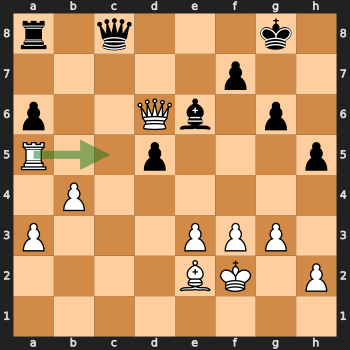

### [0] Position 1 — **Rubinstein – Salwe**
**White plays Rc5** (good , wp_loss=3.1%)

`r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33`

**Gold atoms:**
- Maintains control of the c-file, preventing Black's pieces from occupying it.

{'position_number': 1,
 'fen': 'r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33',
 'move_uci': 'a5c5',
 'move_san': 'Rc5',
 'annotation': 'Not through the Iron Duke! It is more important to retain control of the c-file and to keep Black’s pieces off it than to pick up stray pawns.',
 'wp_loss': 3.06,
 'quality': 'good',
 'game': 'Rubinstein – Salwe',
 'extracted': {'include': True,
  'book_commentary': 'Not through the Iron Duke! It is more important to retain control of the c-file and to keep Black’s pieces off it than to pick up stray pawns.',
  'quality': 'good',
  'reasoning': ["Maintains control of the c-file, preventing Black's pieces from occupying it."]}}

In [56]:
IDX = 0  # ← change this, re-run cells below
show_position(IDX)

In [57]:
show_gen_prompt(IDX)

#### System prompt
```
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN), the move played, and engine analysis, write a concise, instructive explanation of the move.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers.
```

#### Demo 1 — user
```
FEN: r2q1rk1/1b1nbp2/p4np1/3pN1B1/2pP3Q/2p1P3/PPB3PP/R4RK1 w - - 0 18
Move played: Nxd7 [wp_loss: -0.4%]
Engine top-3:
  1. bxc3 (+4.38): bxc3 Qa5 Nxd7 Nxd7 Bxe7 Qxc3 Ba4 Rae8
  2. Nxd7 (+3.92): Nxd7 Nh5 Bxg6 fxg6 Rxf8+ Qxf8 Nxf8 cxb2
  3. Rf3 (+2.89): Rf3 Nxe5 dxe5 Nh5 Bxe7 cxb2 Raf1 Qb6

```

#### Demo 1 — assistant
> Nxd7 removes one of the pieces defending Black's knight on f6, undermining its support.

#### Demo 2 — user
```
FEN: rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8
Move played: Qe5 [wp_loss: 0.0%]
Engine top-3:
  1. Qe5 (+1.18): Qe5 a3 Bxe2 Qxe2 Qxe2+ Kxe2 Bxc3 Bxc3
  2. Qc5 (+2.81): Qc5 Bxg4 Qxd4 Qe2+ Ne7 O-O-O O-O Bg5
  3. Bd7 (+3.16): Bd7 a3 Bxc3 Bxc3 Qb6 Bc4 Ne7 Qh5

```

#### Demo 2 — assistant
> Qe5 pins the bishop on e2 against the king on e1, while simultaneously attacking the unprotected knight on d4. Black avoids 8...Bxe2 because after 9.Qxe2+, White gains a tempo with the check.

...

#### Demo 4 — assistant
> exd4 opens the position to create counterplay — White wants to use the e-file for the rook and the e4-square as a pivot for piece maneuvering. The alternative 12.e4 looks natural but after 12...Qh5, the e4-square is blocked by White's own pawn, removing it as an outpost, and Black gains a dangerous passed d-pawn.

#### Demo 5 — user
```
FEN: r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12
Move played: O-O [BLUNDER — wp_loss: 24.1%]
Engine top-3:
  1. Qd7 (+1.05): Qd7 Qf2 Bf5 Ne1 Nd8 Bc1 Be4 Qg3
  2. Na5 (+1.20): Na5 Bb5+ c6 Bd3 Ng6 Bg3 Nc4 Qf2
  3. Bf5 (+1.37): Bf5 Bxf5 Nxf5 Rbe1 Qd7 Qd3 O-O-O Nd2
Played move eval:
  O-O (+4.70): O-O Bxh6 Ng6 h4 Nxh4 Bg5 Nxf3+ Rxf3

```

#### Demo 5 — assistant
> Castling walks straight into White's prepared kingside attack. Instead, Black should exploit White's one weakness — the doubled c-pawns — with Na5, rerouting the knight toward c4. On c4, the knight blockades the doubled pawn, restricts White's pieces, and if White captures with Bxc4 dxc4, White's pawn structure becomes inferior. Black could also anchor a piece on d5, a square that pawns can never challenge.

#### This position — user
```
FEN: r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33
Move played: Rc5 [wp_loss: 3.1%]
Engine top-3:
  1. Rxa6 (+2.72): Rxa6 Rxa6 Qxa6 Qc3 Qa7 Qc1 h4 Kh7
  2. Rc5 (+2.59): Rc5 Qe8 Rc7 Rd8 Qxa6 d4 Qd3 dxe3+
  3. Qc5 (+2.40): Qc5 Qb7 h4 Kh7 Qd6 Rc8 Rc5 Rxc5

```

'FEN: r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33\nMove played: Rc5 [wp_loss: 3.1%]\nEngine top-3:\n  1. Rxa6 (+2.72): Rxa6 Rxa6 Qxa6 Qc3 Qa7 Qc1 h4 Kh7\n  2. Rc5 (+2.59): Rc5 Qe8 Rc7 Rd8 Qxa6 d4 Qd3 dxe3+\n  3. Qc5 (+2.40): Qc5 Qb7 h4 Kh7 Qd6 Rc8 Rc5 Rxc5\n'

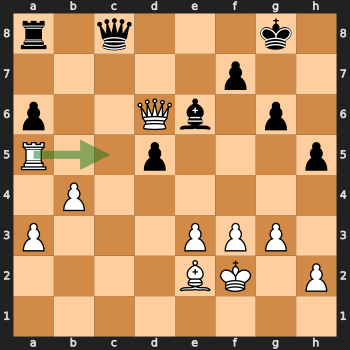

### [0] Position 1 — **Rubinstein – Salwe**
**White plays Rc5** (good , wp_loss=3.1%)

`r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33`

**Gold atoms:**
- Maintains control of the c-file, preventing Black's pieces from occupying it.


Generating (openai/gpt-4o)...


#### Generated
> Rc5 aims to double rooks on the c-file and pressure Black's queen, but it misses the immediate capture Rxa6, which wins a pawn and simplifies the position. After Rxa6, White can follow up with Qxa6, maintaining control and keeping Black's pieces passive.

#### Chernev
> Not through the Iron Duke! It is more important to retain control of the c-file and to keep Black’s pieces off it than to pick up stray pawns.

#### Gold atoms
- Maintains control of the c-file, preventing Black's pieces from occupying it.

In [67]:
gen_text, gen_log = test_gen(IDX)

In [68]:
judge_results = test_judge(IDX, gen_text)

  Decomposing into atoms...
  → 8 atoms
  Verifying atoms against position...
    tool: get_legal_moves({'fen': 'r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33'}) -> {"moves": ["Qf8+", "Qd8+", "Qb8", "Qe7", "Qd7", "Qc7", "Qxe6", "Qc6", "Qb6", "Qx
    tool: get_attacks({'fen': 'r1q3k1/5p2/p2Qb1p1/2Rp3p/1P6/P3PPP1/4BK1P/8 b - - 3 33', 'square': 'c5'}) -> {"piece": "R", "square": "c5", "attacks": ["a5", "b5", "c1", "c2", "c3", "c4", "
    tool: get_piece_at({'fen': 'r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33', 'square': 'a6'}) -> {"square": "a6", "piece": "black pawn"}
    tool: try_variation({'fen': 'r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33', 'moves': ['Rxa6']}) -> {"legal": true, "played": ["Rxa6"], "eval": "+2.14"}
    tool: try_variation({'fen': 'r1q3k1/5p2/p2Qb1p1/R2p3p/1P6/P3PPP1/4BK1P/8 w - - 2 33', 'moves': ['Rxa6', 'Qxa6']}) -> {"legal": true, "played": ["Rxa6", "Qxa6"], "eval": "+6.10"}
  → 4/8 verified
  Matching against 1 gold atoms...
  → 1/1

| Metric | Score |
|--------|-------|
| Factual Precision | **50%** (4/8) |
| Recall | **100%** (1/1) |
| Quality | **correct** |


**Candidate atoms (verified):**

- [Y] Rc5 aims to double rooks on the c-file.  
  *The move Rc5 places the rook on the c-file, and the other rook can move to c1 to double on the c-file.*

- [Y] Rc5 pressures Black's queen.  
  *The rook on c5 attacks the c8 square, where the Black queen is located.*

...

- [N] After Rxa6, White can follow up with Qxa6.  
  *After Rxa6, Qxa6 is not a legal follow-up move for White as it would require capturing their own piece.*

- [N] After Rxa6 and Qxa6, White maintains control.  
  *The sequence Rxa6 followed by Qxa6 is not legal, so this claim is invalid.*

- [N] After Rxa6 and Qxa6, Black's pieces remain passive.  
  *The sequence Rxa6 followed by Qxa6 is not legal, so this claim is invalid.*

**Gold atoms (covered):**

- [Y] Maintains control of the c-file, preventing Black's pieces from occupying it.  
  *matched: Rc5 aims to double rooks on the c-file.*

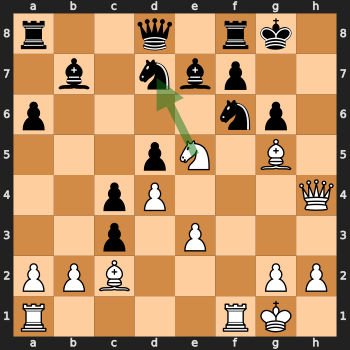

### [3] Position 4 — **Pillsbury – Marco**
**White plays Nxd7** (good , wp_loss=-0.4%)

`r2q1rk1/1b1nbp2/p4np1/3pN1B1/2pP3Q/2p1P3/PPB3PP/R4RK1 w - - 0 18`

**Engine:**
1. **bxc3** (+4.38): bxc3 Qa5 Nxd7 Nxd7 Bxe7 Qxc3 Ba4 Rae8
2. **Nxd7** (+3.92): Nxd7 Nh5 Bxg6 fxg6 Rxf8+ Qxf8 Nxf8 cxb2 <- played
3. **Rf3** (+2.89): Rf3 Nxe5 dxe5 Nh5 Bxe7 cxb2 Raf1 Qb6

**Gold atoms:**
- Nxd7 removes one of the supporting pieces for Black's knight on f6.


Generating (openai/gpt-4o)...


#### Generated
> Nxd7 removes one of the defenders of Black's knight on f6, preparing to capture it next and further weaken Black's kingside. This move also opens the e-file for White's rook, increasing pressure on Black's position.

...

- [Y] Nxd7 further weakens Black's kingside.  
  *The move Nxd7 removes a defender of f6, which is a key square for Black's kingside defense.*

- [N] Nxd7 opens the e-file for White's rook.  
  *The e-file is not opened for White's rook as there are still pawns on e3 and e7.*

- [Y] Nxd7 increases pressure on Black's position.  
  *The move increases pressure by attacking the knight on f6 and removing a defender.*

**Gold atoms (covered):**

- [Y] Nxd7 removes one of the supporting pieces for Black's knight on f6.  
  *matched: Nxd7 removes one of the defenders of Black's knight on f6.*

In [78]:
IDX = 3
gen_text, gen_log = test_gen(IDX)
judge_results = test_judge(IDX, gen_text)


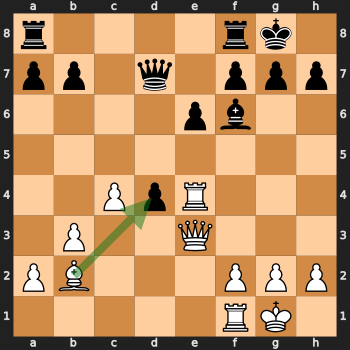

### [4] Position 6 — **Capablanca – Villegas**
**White plays Bxd4** (good , wp_loss=0.0%)

`r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19`

**Engine:**
1. **Bxd4** (+0.52): Bxd4 Bxd4 Rxd4 Qe7 Rfd1 Rfd8 g3 b6 <- played
2. **Qd3** (-1.66): Qd3 Rfd8 Bc1 Rac8 h4 Rc5 a4 h6
3. **Qf3** (-1.76): Qf3 Rfe8 Rfe1 e5 g4 Qc6 Qd3 h6

**Gold atoms:**
- Regains the pawn on d4.
- The bishop on d4 attacks both the a7-pawn and threatens a mating sequence starting with Bxf6.


Generating (openai/gpt-4o)...


#### Generated
> Bxd4 captures the pawn and opens the e3-square for the queen, enabling White to potentially double rooks on the d-file. This move also prevents Black from playing ...d3, which would have created a strong passed pawn.

...

- [Y] Bxd4 prevents Black from playing ...d3.  
  *The tool showed that ...d3 is illegal after Bxd4.*

- [N] If Black plays ...d3, it would create a strong passed pawn.  
  *The tool showed that ...d3 is illegal after Bxd4, so this scenario cannot occur.*

**Gold atoms (covered):**

- [Y] Regains the pawn on d4.  
  *matched: Bxd4 captures the pawn on d4.*

- [N] The bishop on d4 attacks both the a7-pawn and threatens a mating sequence starting with Bxf6.

In [79]:
IDX = 4
gen_text, gen_log = test_gen(IDX)
judge_results = test_judge(IDX, gen_text)


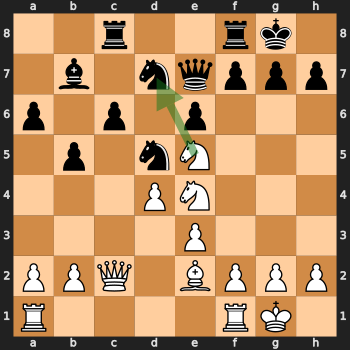

### [5] Position 7 — **Chekhover – Rudakowsky**
**White plays Nxd7** (good , wp_loss=0.0%)

`2r2rk1/1b1nqppp/p1p1p3/1p1nN3/3PN3/4P3/PPQ1BPPP/R4RK1 w - - 4 15`

**Engine:**
1. **Nxd7** (+2.00): Nxd7 Qxd7 Nc5 Qe7 Rfc1 h6 Bf3 Rfd8 <- played
2. **Rfc1** (+1.40): Rfc1 Nxe5 dxe5 c5 Nd6 Rc6 a4 b4
3. **Nd3** (+0.93): Nd3 e5 Nxe5 Nxe5 dxe5 Rcd8 Bf3 Qxe5

**Gold atoms:**
- Nxd7 removes a piece that is guarding the c5-square.


Generating (openai/gpt-4o)...


#### Generated
> Nxd7 captures the knight on d7, which is a key defender of the e5-square. By removing this knight, White prepares to exert more pressure on e5 and c5, while also opening the c-file for potential rook activity.

...

- [Y] By removing the knight on d7, White prepares to exert more pressure on e5.  
  *The tool showed that after the move, White has a pawn and the knight on d7 attacking e5.*

- [Y] By removing the knight on d7, White prepares to exert more pressure on c5.  
  *The tool showed that after the move, White has a queen, a pawn, a knight on e4, and the knight on d7 attacking c5.*

- [N] By removing the knight on d7, White opens the c-file for potential rook activity.  
  *The tool showed that there are no white rooks on the c-file after the move.*

**Gold atoms (covered):**

- [Y] Nxd7 removes a piece that is guarding the c5-square.  
  *matched: By removing the knight on d7, White prepares to exert more pressure on c5.*

In [85]:
IDX = 5
gen_text, gen_log = test_gen(IDX)
judge_results = test_judge(IDX, gen_text)


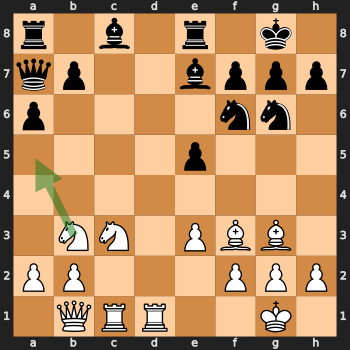

### [6] Position 9 — **Rubinstein – Maroczy**
**White plays Na5** (good , wp_loss=4.1%)

`r1b1r1k1/qp2bppp/p4nn1/4p3/8/1NN1PBB1/PP3PPP/1QRR2K1 w - - 6 19`

**Engine:**
1. **h4** (+1.94): h4 h5 Nd5 Nxd5 Bxd5 Kf8 Qe4 Bg4
2. **Na5** (+1.64): Na5 Bg4 Bxg4 Nxg4 Nd5 Bd8 b4 h5 <- played
3. **Nd2** (+1.09): Nd2 Be6 h4 h5 Nde4 Rad8 Nxf6+ Bxf6

**Gold atoms:**
- Na5 prevents 19...Rb8 followed by 20...b5 because 21.Nc6 would win the exchange.
- 19...Bd7 or 19...Be6 would lose Black's b-pawn.


Generating (openai/gpt-4o)...


#### Generated
> Na5 aims to reposition the knight to a more active square, potentially targeting c6 or b7, and indirectly supports the b7-pawn advance. However, the move allows Black to play Bg4, exchanging off a key defender of White's central squares. Instead, h4 would have been more aggressive, preparing to open lines against Black's king.

...

- [N] Na5 indirectly supports the b7-pawn advance.  
  *tool showed b7 is a black pawn, and Na5 does not support its advance.*

- [Y] After Na5, Black can play Bg4, exchanging off a key defender of White's central squares.  
  *tool showed Bg4 is a legal move for Black.*

**Gold atoms (covered):**

- [Y] Na5 prevents 19...Rb8 followed by 20...b5 because 21.Nc6 would win the exchange.  
  *matched: Na5 aims to reposition the knight to a more active square, potentially targeting c6 or b7.*

- [N] 19...Bd7 or 19...Be6 would lose Black's b-pawn.

In [87]:
IDX = 6
gen_text, gen_log = test_gen(IDX)
judge_results = test_judge(IDX, gen_text)


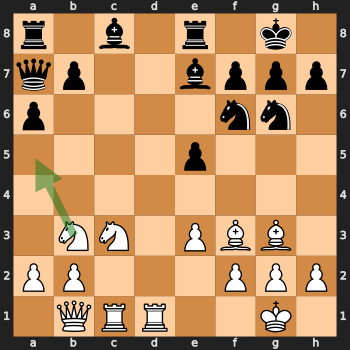

### [6] Position 9 — **Rubinstein – Maroczy**
**White plays Na5** (good , wp_loss=4.1%)

`r1b1r1k1/qp2bppp/p4nn1/4p3/8/1NN1PBB1/PP3PPP/1QRR2K1 w - - 6 19`

**Engine:**
1. **h4** (+1.94): h4 h5 Nd5 Nxd5 Bxd5 Kf8 Qe4 Bg4
2. **Na5** (+1.64): Na5 Bg4 Bxg4 Nxg4 Nd5 Bd8 b4 h5 <- played
3. **Nd2** (+1.09): Nd2 Be6 h4 h5 Nde4 Rad8 Nxf6+ Bxf6

**Gold atoms:**
- Na5 prevents 19...Rb8 followed by 20...b5 because 21.Nc6 would win the exchange.
- 19...Bd7 or 19...Be6 would lose Black's b-pawn.


Generating (openai/gpt-5.2)...


#### Generated
> Na5 is a concrete try to hit Black’s queen on a7 and gain a tempo, but the knight on a5 is also pushed to the rim where it stops influencing the center and can be met by …Bg4, when your queen on b1 and bishop on f3 both come under pressure. After 19.Na5 Bg4 20.Bxg4 Nxg4 Black’s pieces become more active and your a5-knight has no good follow-up squares, so you’ve spent a move for a queen “poke” without improving your position. The engine’s 19.h4 is stronger because it immediately challenges …h5 and creates a direct kingside plan; if Black answers …h5, then Nd5 jumps into the center with tempo and your bishops on f3/g3 start to bite.

#### Chernev
> A fine preventive move! It stops 19... Rb8 followed by 20... b5 as then 21 Nc6 wins the exchange, while the direct 19... Bd7 or 19... Be6 costs Black his b-pawn.
Notice how White not only sees to the development of his own pieces but hinders that of his opponent.

#### Gold atoms
- Na5 prevents 19...Rb8 followed by 20...b5 because 21.Nc6 would win the exchange.
- 19...Bd7 or 19...Be6 would lose Black's b-pawn.

In [111]:
IDX = 6
gen_text, gen_log = test_gen(IDX, provider='openai', model = 'gpt-5.2', ascii = True)


In [112]:
judge_results = test_judge(IDX, gen_text)

  Decomposing into atoms...
  → 8 atoms
  Verifying atoms against position...
    tool: get_attacks({'fen': 'r1b1r1k1/qp2bppp/p4nn1/N3p3/8/2N1PBB1/PP3PPP/1QRR2K1', 'square': 'a5'}) -> {"piece": "N", "square": "a5", "attacks": ["b3", "b7", "c4", "c6"]}
    tool: get_piece_at({'fen': 'r1b1r1k1/qp2bppp/p4nn1/N3p3/8/2N1PBB1/PP3PPP/1QRR2K1', 'square': 'a7'}) -> {"square": "a7", "piece": "black queen"}
    tool: get_attacks({'fen': 'r1b1r1k1/qp2bppp/p4nn1/N3p3/8/2N1PBB1/PP3PPP/1QRR2K1', 'square': 'a5'}) -> {"piece": "N", "square": "a5", "attacks": ["b3", "b7", "c4", "c6"]}
    tool: get_legal_moves({'fen': 'r1b1r1k1/qp2bppp/p4nn1/N3p3/8/2N1PBB1/PP3PPP/1QRR2K1'}) -> {"moves": ["Nxb7", "Nc6", "Nc4", "Nb3", "Bxe5", "Bh4", "Bf4", "Bxb7", "Bc6", "Bh
    tool: get_attacks({'fen': 'r1b1r1k1/qp2bppp/p4nn1/N3p3/8/2N1PBB1/PP3PPP/1QRR2K1', 'square': 'g4'}) -> {"error": "no piece on g4"}
    tool: get_piece_at({'fen': 'r1b1r1k1/qp2bppp/p4nn1/N3p3/8/2N1PBB1/PP3PPP/1QRR2K1', 'square': 'b1'}) -> {"square":

| Metric | Score |
|--------|-------|
| Factual Precision | **38%** (3/8) |
| Recall | **0%** (0/2) |
| Quality | **correct** (gen=inconclusive, actual=good) |


**Generated atoms:**
1. Na5 attacks Black’s queen on a7 and gains a tempo.
2. After Na5, the knight on a5 is on the rim and stops influencing the center.
3. After Na5, Black can play Bg4, putting pressure on White's queen on b1 and bishop on f3.
4. After Na5 Bg4 20.Bxg4 Nxg4, Black’s pieces become more active.
5. After Na5 Bg4 20.Bxg4 Nxg4, White's knight on a5 has no good follow-up squares.
6. The engine suggests 19.h4 as stronger than Na5 because it challenges …h5 and creates a direct kingside plan.
7. After 19.h4, if Black plays …h5, then Nd5 jumps into the center with tempo.
8. After 19.h4 and …h5, White's bishops on f3 and g3 become more active.

**Candidate atoms (verified):**

- [Y] Na5 attacks Black’s queen on a7 and gains a tempo.  
  *The knight on a5 attacks b7, where the black queen is located, thus gaining a tempo by attacking the queen.*

...

- [Y] After 19.h4, if Black plays …h5, then Nd5 jumps into the center with tempo.  
  *After h4 and h5, Nd5 is a legal move that attacks multiple squares, including the pawn on e7, gaining a tempo.*

- [N] After 19.h4 and …h5, White's bishops on f3 and g3 become more active.  
  *There is no bishop on g3 in the post-move position.*

**Gold atoms (covered):**

- [N] Na5 prevents 19...Rb8 followed by 20...b5 because 21.Nc6 would win the exchange.

- [N] 19...Bd7 or 19...Be6 would lose Black's b-pawn.